In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [150]:
def load_prices():
    # Load the data
    data = pd.read_csv('Inputs/lastPrices_NAV.txt')
    data.columns = ['TICKER', 'DATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
    
    # Filter out invalid dates and convert to datetime
    data = data[data['DATE'] != 'DATE.trans(-)']
    data['DATE'] = pd.to_datetime(data['DATE'], format='%Y%m%d')
    
    # Convert the numeric columns
    cols_to_convert = data.columns.difference(['TICKER', 'DATE'])
    data[cols_to_convert] = data[cols_to_convert].apply(pd.to_numeric, errors='coerce')
    
    return data

def fill_missing_dates(data):
    # Copy relevant columns: 'TICKER', 'DATE', and 'CLOSE' for further processing
    price_close = data[['TICKER', 'DATE', 'CLOSE']].copy()
    
    # Pivot the data: Use 'DATE' as the index and 'TICKER' as the columns, with 'CLOSE' as values
    # This transforms the data to a wide format, where each ticker has its own column
    price_close_pivoted = price_close.pivot(index='DATE', columns='TICKER', values='CLOSE')
    
    # Reset the index to turn 'DATE' back into a column instead of the index
    price_close_pivoted.reset_index(inplace=True)
    
    # Remove the 'name' attribute from the columns to clean up the display of the DataFrame
    price_close_pivoted.columns.name = None

    # Generate a full date range from the minimum to the maximum date in the dataset
    # This ensures all possible dates, including weekends or holidays, are included
    data_dates = data['DATE'].drop_duplicates()  # Get unique dates
    full_dates_series = pd.date_range(start=data_dates.min(), end=data_dates.max(), freq='D')
    
    # Create a new DataFrame with all dates and merge it with the pivoted data to include missing dates
    price_close_fdays = pd.DataFrame(full_dates_series, columns=['DATE']).merge(price_close_pivoted, on='DATE', how='left')

    # Fill missing values: Forward-fill ('ffill') propagates the last valid observation to fill missing entries
    # This means the previous day's price will be carried forward for any missing date
    price_close_fdays.ffill(inplace=True)

    # Unpivot the data back to long format using pd.melt
    # 'id_vars' keeps 'DATE' as its own column, while 'TICKER' becomes a column
    # Each ticker's 'CLOSE' price is placed into its own row
    prices_close_melt = pd.melt(price_close_fdays, id_vars=['DATE'], var_name='TICKER', value_name='CLOSE')

    # Return the final long-format DataFrame with all dates and missing values filled
    return prices_close_melt


# Load and preprocess the data
data = load_prices()
trading_dates = data['DATE'].sort_values().drop_duplicates().reset_index(drop=True)

# Fill the missing dates
prices = fill_missing_dates(data)

# Dates
prices['Date_quarter'] = prices['DATE'].dt.to_period('Q')
prices.rename(columns={'DATE': 'Date', 'TICKER': 'ID', 'CLOSE' : 'Price'}, inplace=True)

prices

,Date,ID,Price,Date_quarter
0,2014-11-28,AGUAS-A,365.09,2014Q4
1,2014-11-29,AGUAS-A,365.09,2014Q4
2,2014-11-30,AGUAS-A,365.09,2014Q4
3,2014-12-01,AGUAS-A,362.06,2014Q4
4,2014-12-02,AGUAS-A,364.47,2014Q4
...,...,...,...,...
54805,2024-11-24,VAPORES,52.51,2024Q4
54806,2024-11-25,VAPORES,52.02,2024Q4
54807,2024-11-26,VAPORES,52.01,2024Q4
54808,2024-11-27,VAPORES,52.30,2024Q4


In [151]:
##### Import the data

# Ticker Guide
tickers = pd.read_csv('Inputs/tickers.csv')

# Balance Sheets
balance_comp = pd.read_csv('balance_sheets_com_db.csv')
balance_hol = pd.read_csv('balance_sheets_hol_db.csv')
balance = pd.concat([balance_comp, balance_hol])
balance.drop(balance.columns[0], axis=1, inplace=True)

balance['Date'] = pd.to_datetime(balance['Date'])

balance['Value'] = balance['Value'].apply(lambda x: '0' if x == '-' else x)  # Replace standalone '-' with '0'
balance['Value'] = balance['Value'].str.replace('.', '', regex=False)  # Remove thousand separators
balance['Value'] = balance['Value'].str.replace(',', '.', regex=False)  # Replace comma with period for decimal
balance['Value'] = balance['Value'].astype(float) # Convert to float

# FX
fx = pd.read_csv('Inputs/usdclp.csv')
fx.columns = ['Date', 'USDCLP']
#fx['USDCLP'] = fx['USDCLP'].str.replace(',', '').astype(float)
fx['Date'] = pd.to_datetime(fx['Date'])


In [152]:
# NetDebt - Balance Guide
netdebt_guide = pd.read_csv('balance_netdebt.csv', sep = ";")
id_holding = netdebt_guide[['Holding', 'ID']].drop_duplicates().copy()
prices_final = prices.merge(id_holding, on='ID', how='inner')

prices_final

,Date,ID,Price,Date_quarter,Holding
0,2014-11-28,AGUAS-A,365.09,2014Q4,IAM
1,2014-11-29,AGUAS-A,365.09,2014Q4,IAM
2,2014-11-30,AGUAS-A,365.09,2014Q4,IAM
3,2014-12-01,AGUAS-A,362.06,2014Q4,IAM
4,2014-12-02,AGUAS-A,364.47,2014Q4,IAM
...,...,...,...,...,...
29227,2024-11-24,INVERCAP,1636.30,2024Q4,INVERCAP
29228,2024-11-25,INVERCAP,1607.30,2024Q4,INVERCAP
29229,2024-11-26,INVERCAP,1610.00,2024Q4,INVERCAP
29230,2024-11-27,INVERCAP,1604.90,2024Q4,INVERCAP


In [153]:
# Ajuste manual de ANTARCHILE
balance.loc[balance['ID'] == 'ANTARCHILE', 'Curncy'] = 'USD'

# Fix by FX
balance_usd = balance[balance['Curncy'] == 'USD'].copy()
balance_no_usd = balance[balance['Curncy'] != 'USD'].copy() 
balance_usd = balance_usd.merge(fx, on='Date', how='inner')
balance_usd['Value'] = (balance_usd['Value'] * balance_usd['USDCLP'])
balance_usd.drop('USDCLP', axis=1, inplace=True)
balance_usd.to_csv('balance_usd.csv', index=False)

# Balance Total
balance_total = pd.concat([balance_no_usd, balance_usd])
balance_total['Value'] = balance_total['Value']/1000
balance_total.drop('Curncy', axis=1, inplace=True)
balance_total.to_csv('balance_total.csv', index=False)
balance_total

,Description,Value,Date,ID
0,Efectivo y equivalentes al efectivo,4.963128e+04,2018-03-31,ENTEL
1,Otros activos financieros corrientes,1.520074e+03,2018-03-31,ENTEL
2,Otros activos no financieros corrientes,9.760527e+04,2018-03-31,ENTEL
3,Deudores comerciales y otras cuentas por cobra...,3.940893e+05,2018-03-31,ENTEL
4,"Cuentas por cobrar a entidades relacionadas, c...",2.861200e+02,2018-03-31,ENTEL
...,...,...,...,...
8996,Otras reservas,-1.618881e+06,2024-06-30,ANTARCHILE
8997,Patrimonio atribuible a los propietarios de la...,7.336474e+06,2024-06-30,ANTARCHILE
8998,Participaciones no controladoras,5.053232e+06,2024-06-30,ANTARCHILE
8999,Patrimonio total,1.238971e+07,2024-06-30,ANTARCHILE


In [154]:
# Balance Total solamente con las partidas correspondientes a NetDebt
balance_sel = balance_total.merge(netdebt_guide, on=['ID', 'Description'], how='inner').merge(tickers, on='ID', how='inner')[['Date', 'ID', 'Holding', 'IS_HOLDING','Description', 'Balance2', 'Value']]
balance_sel.to_csv('balance_selected_netdebt.csv', index=False)
balance_sel

,Date,ID,Holding,IS_HOLDING,Description,Balance2,Value
0,2018-03-31,ENTEL,ALMENDRAL,-1,Efectivo y equivalentes al efectivo,Cash,4.963128e+04
1,2018-06-30,ENTEL,ALMENDRAL,-1,Efectivo y equivalentes al efectivo,Cash,3.241612e+04
2,2018-09-30,ENTEL,ALMENDRAL,-1,Efectivo y equivalentes al efectivo,Cash,9.116118e+03
3,2018-12-31,ENTEL,ALMENDRAL,-1,Efectivo y equivalentes al efectivo,Cash,7.274825e+04
4,2019-03-31,ENTEL,ALMENDRAL,-1,Efectivo y equivalentes al efectivo,Cash,3.432287e+04
...,...,...,...,...,...,...,...
827,2023-06-30,ANTARCHILE,ANTARCHILE,1,Otros pasivos financieros no corrientes,Debt,6.451639e+06
828,2023-09-30,ANTARCHILE,ANTARCHILE,1,Otros pasivos financieros no corrientes,Debt,6.693074e+06
829,2023-12-31,ANTARCHILE,ANTARCHILE,1,Otros pasivos financieros no corrientes,Debt,6.854222e+06
830,2024-03-31,ANTARCHILE,ANTARCHILE,1,Otros pasivos financieros no corrientes,Debt,7.417301e+06


In [155]:
# Preparación de la data para el cálculo de NetDebt
balance_sel['Value'] = np.where(balance_sel['IS_HOLDING'] == -1, (-1 * balance_sel['Value']), (1 * balance_sel['Value']))

# Cálculo de NetDebt por Empresa (Subsidiarias y Holding)
balance_group = balance_sel.groupby(['ID', 'Date', 'Balance2']).agg({'Value': 'sum'}).reset_index().copy()
balance_group.to_csv('balance_netdebt_comp_hol.csv', index=False)

# Creamos una dataframe que nos ayuda a eliminar datos que aun no se han consolidado
id_date_max = balance_group[['ID', 'Date']].copy().drop_duplicates()
id_date_max = id_date_max.merge(tickers, on=['ID'], how='left')[['Date', 'ID', 'IS_HOLDING']].drop_duplicates()
hol_date_max = id_date_max[id_date_max['IS_HOLDING'] == 1][['ID', 'Date']]
hol_date_max['Date_quarter'] = hol_date_max['Date'].dt.to_period('Q')
hol_date_max.drop('Date', axis=1, inplace=True)

hol_date_max.columns = ['Holding', 'Date_quarter']
hol_date_max.to_csv('Holding_Max_Report.csv')


In [156]:
# Consolidamos las partidas relacionadas al NetDebt a nivel de Holding
balance_group_2 = balance_group.merge(id_holding).groupby(['Date', 'Holding', 'Balance2']).agg({'Value': 'sum'}).reset_index().copy()
balance_group_2

,Date,Holding,Balance2,Value
0,2018-03-31,ALMENDRAL,Cash,19388.23800
1,2018-03-31,ALMENDRAL,Debt,70563.82600
2,2018-03-31,ANTARCHILE,Cash,69162.45494
3,2018-03-31,ANTARCHILE,Debt,119868.11144
4,2018-03-31,IAM,Cash,731.26800
...,...,...,...,...
203,2024-06-30,ANTARCHILE,Debt,143574.53838
204,2024-06-30,IAM,Cash,2009.31800
205,2024-06-30,IAM,Debt,0.00000
206,2024-06-30,INVERCAP,Cash,5175.45084


In [157]:
# Cambiamos el signo de las partidas de Cash y Debt
balance_group_2['NetDebt'] = np.where(balance_group_2['Balance2'] == 'Cash', balance_group_2['Value'] * -1, balance_group_2['Value'])

# Calculo inicial del NetDebt
netdebt = balance_group_2.groupby(['Date', 'Holding']).agg({'NetDebt': 'sum'}).reset_index().copy()
netdebt['Date_quarter'] = netdebt['Date'].dt.to_period('Q')
netdebt.drop('Date', axis=1, inplace=True)

# Realizamos un join-left para eliminar los NetDebt no he consolidado aun, y que si muestra algo es por que las subsidirias ya consolidaron
netdebt_corrected_dt = hol_date_max.merge(netdebt, on=['Holding', 'Date_quarter'], how='left')
#netdebt_corrected_dt.to_csv('netdebt.csv', index=False)

netdebt_corrected_dt = pd.read_csv('netdebt.csv', sep = ";")
netdebt_corrected_dt['NetDebt'] = netdebt_corrected_dt['NetDebt'].str.replace(',', '', regex = True).str.strip()
netdebt_corrected_dt['NetDebt'] = pd.to_numeric(netdebt_corrected_dt['NetDebt'], errors='coerce')
netdebt_corrected_dt['Date_quarter'] = pd.PeriodIndex(netdebt_corrected_dt['Date_quarter'], freq = 'Q')

min_date = netdebt_corrected_dt.loc[netdebt_corrected_dt['NetDebt'].notna(), 'Date_quarter'].min()
min_date_final = min_date.start_time

# Realizamos un ffll para completar los datos faltantes
dates_holding = prices_final[['Date', 'Holding']].copy()
dates_holding['Date_quarter'] = dates_holding['Date'].dt.to_period('Q')
dates_holding_final = dates_holding[dates_holding['Date'] >= min_date_final].copy()

netdebt_final_dt = dates_holding_final.merge(netdebt_corrected_dt, on=['Date_quarter' ,'Holding'], how='left')
netdebt_final_dt['NetDebt'] = netdebt_final_dt.groupby('Holding')['NetDebt'].ffill()
netdebt_final_dt.reset_index(drop=True, inplace=True)
netdebt_final_dt.drop_duplicates(inplace=True)
netdebt_final_dt


,Date,Holding,Date_quarter,NetDebt
0,2018-01-01,IAM,2018Q1,-731.0
1,2018-01-02,IAM,2018Q1,-731.0
2,2018-01-03,IAM,2018Q1,-731.0
3,2018-01-04,IAM,2018Q1,-731.0
4,2018-01-05,IAM,2018Q1,-731.0
...,...,...,...,...
10091,2024-11-24,INVERCAP,2024Q4,28117.0
10092,2024-11-25,INVERCAP,2024Q4,28117.0
10093,2024-11-26,INVERCAP,2024Q4,28117.0
10094,2024-11-27,INVERCAP,2024Q4,28117.0


In [158]:
# El ownership de los holding solamente es usado para obtener el numero de acciones que poseen
ownership_hol = pd.read_csv('ownership_data_hol_db.csv', sep =",")
ownership_hol.drop(ownership_hol.columns[0], axis=1, inplace=True)
ownership_hol['Date'] = pd.to_datetime(ownership_hol['Date'])
ownership_hol['Date_quarter'] = ownership_hol['Date'].dt.to_period('Q')
holding_shares = ownership_hol[['ID', 'Date_quarter', 'eqy_shares_total']].copy()
holding_shares['eqy_shares_total'] = holding_shares['eqy_shares_total'].astype(float) / 1000000
holding_shares.drop_duplicates(inplace=True)
holding_shares.columns = ['Holding', 'Date_quarter', 'eqy_shares_total']

holding_shares_dt = dates_holding.merge(holding_shares, on=['Date_quarter' ,'Holding'], how='left')
min_date_hs = holding_shares_dt.loc[holding_shares_dt['eqy_shares_total'].notna(), 'Date'].min()
holding_shares_final = holding_shares_dt[holding_shares_dt['Date'] >= min_date_final].copy()
holding_shares_final['eqy_shares_total'] = holding_shares_final.groupby('Holding')['eqy_shares_total'].ffill()
holding_shares_final.reset_index(drop=True, inplace=True)
holding_shares_final.drop_duplicates(inplace=True)
holding_shares_final

holding_shares_final



,Date,Holding,Date_quarter,eqy_shares_total
0,2018-01-01,IAM,2018Q1,1000.000000
1,2018-01-02,IAM,2018Q1,1000.000000
2,2018-01-03,IAM,2018Q1,1000.000000
3,2018-01-04,IAM,2018Q1,1000.000000
4,2018-01-05,IAM,2018Q1,1000.000000
...,...,...,...,...
10091,2024-11-24,INVERCAP,2024Q4,149.430255
10092,2024-11-25,INVERCAP,2024Q4,149.430255
10093,2024-11-26,INVERCAP,2024Q4,149.430255
10094,2024-11-27,INVERCAP,2024Q4,149.430255


In [159]:
# Consolidamos los ownership de las empresas subsidiarias
ownership = pd.read_csv('ownership_data_com_db.csv')
ownership.drop(ownership.columns[0], axis=1, inplace=True)

ownership['Date'] = pd.to_datetime(ownership['Date'])

#Create the holdings_dict
holdings_dict = {
    'INV ALTEL LTDA': 'ALMENDRAL',
    'ALMENDRAL S A': 'ALMENDRAL',
    'INV AGUAS METROPOLITANAS S A': 'IAM',
    'INVERCAP S.A.': 'INVERCAP',
    'INVERCAP SA': 'INVERCAP',
    'ANTARCHILE S.A.': 'ANTARCHILE',
}

ownership = ownership[ownership['Holding'].isin(holdings_dict.keys())]
ownership['Holding'] = ownership['Holding'].map(holdings_dict)

ownership = ownership.merge(tickers, on='ID', how='inner')[['Date', 'ID', 'Holding', 'pct_holding', 'eqy_shares_total']]

# Debemos de dividir por un millon a las acciones dado que los otros datos tambien estan en un millon
ownership['eqy_shares_total'] = ownership['eqy_shares_total'] / 1000000
ownership['Date_quarter'] = ownership['Date'].dt.to_period('Q')
ownership.drop('Date', axis=1, inplace=True)
ownership[ownership['Holding'] == 'ANTARCHILE']

,ID,Holding,pct_holding,eqy_shares_total,Date_quarter
78,COLBUN,ANTARCHILE,0.0958,17534.488863,2018Q1
79,COLBUN,ANTARCHILE,0.0958,17534.488863,2018Q2
80,COLBUN,ANTARCHILE,0.0958,17534.488863,2018Q3
81,COLBUN,ANTARCHILE,0.0958,17534.488863,2018Q4
82,COLBUN,ANTARCHILE,0.0958,17534.488863,2019Q1
...,...,...,...,...,...
151,NUTRAVALOR,ANTARCHILE,0.1870,310.881888,2023Q2
152,NUTRAVALOR,ANTARCHILE,0.1870,310.881888,2023Q3
153,NUTRAVALOR,ANTARCHILE,0.1870,310.881888,2023Q4
154,NUTRAVALOR,ANTARCHILE,0.1870,310.881888,2024Q1


In [160]:
id_holding_2 = pd.read_csv('id_holding_2.csv', sep = ";")

def process_ownership_data(prices, id_holding_2, ownership):
    # Merge prices with id_holding
    prices_final = prices.merge(id_holding_2, on='ID', how='inner')
    holdings = id_holding_2['Holding'].unique()

    prices_final = prices_final[-(prices_final['ID'].isin(holdings))].copy()

    # Merge with ownership data
    columns_to_keep = ['Date', 'Date_quarter', 'ID', 'Holding', 'pct_holding', 'Price', 'eqy_shares_total']
    prices_ownership = prices_final.merge(
        ownership, 
        on=['ID', 'Holding', 'Date_quarter'], 
        how='left'
    )[columns_to_keep]
    
    # Find the earliest date with non-null pct_holding
    min_date = prices_ownership.loc[prices_ownership['pct_holding'].notna(), 'Date'].min()
    
    # Set Date as index and filter from min_date onwards
    filtered_prices_ownership = prices_ownership[prices_ownership['Date'] >= min_date].copy()
    
    # Forward fill missing values
    filtered_prices_ownership['pct_holding'] = filtered_prices_ownership.groupby('ID')['pct_holding'].ffill()
    filtered_prices_ownership['eqy_shares_total'] = filtered_prices_ownership.groupby('ID')['eqy_shares_total'].ffill()
    filtered_prices_ownership.reset_index(drop=True, inplace=True)
    
    return filtered_prices_ownership

# Usage:
price_ownership = process_ownership_data(prices, id_holding_2, ownership)
price_ownership.to_csv('price_ownership.csv', index=False)
price_ownership

,Date,Date_quarter,ID,Holding,pct_holding,Price,eqy_shares_total
0,2018-01-01,2018Q1,AGUAS-A,IAM,0.5010,407.40,6119.250519
1,2018-01-02,2018Q1,AGUAS-A,IAM,0.5010,409.28,6119.250519
2,2018-01-03,2018Q1,AGUAS-A,IAM,0.5010,407.93,6119.250519
3,2018-01-04,2018Q1,AGUAS-A,IAM,0.5010,408.97,6119.250519
4,2018-01-05,2018Q1,AGUAS-A,IAM,0.5010,411.62,6119.250519
...,...,...,...,...,...,...,...
12615,2024-11-24,2024Q4,ENTEL,ALMENDRAL,0.5486,3030.00,301.994353
12616,2024-11-25,2024Q4,ENTEL,ALMENDRAL,0.5486,2980.00,301.994353
12617,2024-11-26,2024Q4,ENTEL,ALMENDRAL,0.5486,2936.20,301.994353
12618,2024-11-27,2024Q4,ENTEL,ALMENDRAL,0.5486,2911.00,301.994353


In [161]:
# Obtenemos los valores de HoldingValue = MarketCap Subsidiaria * pct_holding
price_ownership['MarketCap'] = price_ownership['Price'] * price_ownership['eqy_shares_total']

price_ownership['HoldingValue'] = (price_ownership['MarketCap'] * price_ownership['pct_holding'])
price_ownership

price_ownership.to_csv('info_prices_ownership.csv')

prices_ownership = price_ownership.groupby(['Date', 'Date_quarter','Holding']).agg({'HoldingValue': 'sum'}).reset_index().copy()
prices_ownership.to_csv('prices_ownership.csv')

prices_ownership.drop_duplicates(inplace=True)
prices_ownership

,Date,Date_quarter,Holding,HoldingValue
0,2018-01-01,2018Q1,ALMENDRAL,1.145355e+06
1,2018-01-01,2018Q1,ANTARCHILE,7.918582e+06
2,2018-01-01,2018Q1,IAM,1.248984e+06
3,2018-01-01,2018Q1,INVERCAP,3.679012e+05
4,2018-01-02,2018Q1,ALMENDRAL,1.149513e+06
...,...,...,...,...
10091,2024-11-27,2024Q4,INVERCAP,3.472823e+05
10092,2024-11-28,2024Q4,ALMENDRAL,4.839341e+05
10093,2024-11-28,2024Q4,ANTARCHILE,5.019877e+06
10094,2024-11-28,2024Q4,IAM,9.196007e+05


In [162]:
# Combinamos Price Ownership con NetDebt
holdings = id_holding['Holding'].unique()
prices_holding = prices_final[(prices_final['ID'].isin(holdings))][['Date', 'Date_quarter','Holding', 'Price']]

nav = prices_ownership.merge(netdebt_final_dt, on=['Holding', 'Date', 'Date_quarter'], how='inner')[['Date', 'Date_quarter', 'Holding', 'HoldingValue', 'NetDebt']]
nav['NAV'] = nav['HoldingValue'] - nav['NetDebt']

nav_final = nav.merge(holding_shares_final, on=['Holding', 'Date','Date_quarter'], how='inner')[['Date', 'Date_quarter', 'Holding', 'HoldingValue', 'NetDebt', 'NAV', 'eqy_shares_total']]
nav_final['NAV_PS'] = nav_final['NAV'] / nav_final['eqy_shares_total']

# Calculamos el descuento
nav_final = nav_final.merge(prices_holding, on=['Date', 'Date_quarter','Holding'], how='left')

nav_final['Discount'] = ((nav_final['Price'] / nav_final['NAV_PS']) - 1) * -1
nav_final.sort_values(by=['Holding', 'Date'], inplace=True)

nav_final.reset_index(inplace= True, drop=True)
nav_final = nav_final[nav_final['Date'].isin(trading_dates)]

nav_final.to_csv('nav.csv', index=False)
nav_final

,Date,Date_quarter,Holding,HoldingValue,NetDebt,NAV,eqy_shares_total,NAV_PS,Price,Discount
1,2018-01-02,2018Q1,ALMENDRAL,1.149513e+06,51176.0,1.098337e+06,18017.388155,60.959845,52.00,0.146979
2,2018-01-03,2018Q1,ALMENDRAL,1.148933e+06,51176.0,1.097757e+06,18017.388155,60.927662,52.25,0.142426
3,2018-01-04,2018Q1,ALMENDRAL,1.199099e+06,51176.0,1.147923e+06,18017.388155,63.711979,53.42,0.161539
4,2018-01-05,2018Q1,ALMENDRAL,1.202512e+06,51176.0,1.151336e+06,18017.388155,63.901400,53.57,0.161677
7,2018-01-08,2018Q1,ALMENDRAL,1.185713e+06,51176.0,1.134537e+06,18017.388155,62.969004,54.00,0.142435
...,...,...,...,...,...,...,...,...,...,...
10089,2024-11-22,2024Q4,INVERCAP,3.547264e+05,28117.0,3.266094e+05,149.430255,2185.697688,1636.30,0.251360
10092,2024-11-25,2024Q4,INVERCAP,3.476059e+05,28117.0,3.194889e+05,149.430255,2138.047233,1607.30,0.248239
10093,2024-11-26,2024Q4,INVERCAP,3.494831e+05,28117.0,3.213661e+05,149.430255,2150.609626,1610.00,0.251375
10094,2024-11-27,2024Q4,INVERCAP,3.472823e+05,28117.0,3.191653e+05,149.430255,2135.881303,1604.90,0.248601


<Axes: title={'center': 'Discount'}, xlabel='Date'>

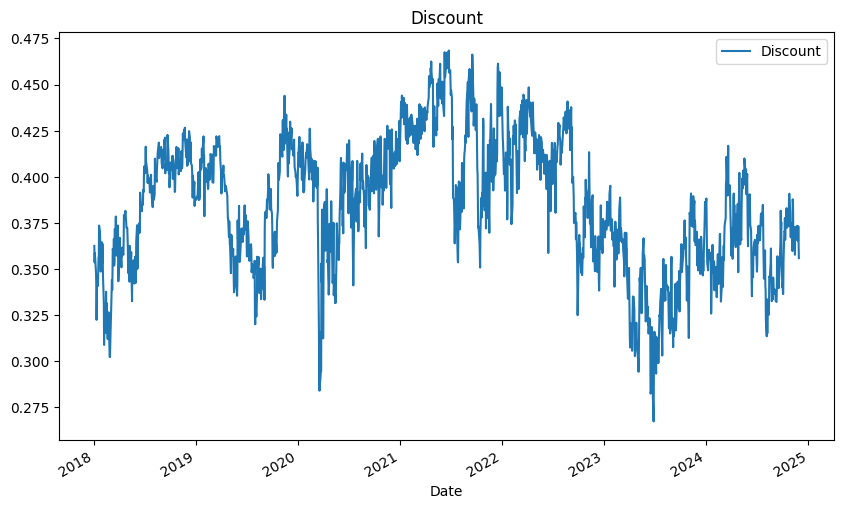

In [163]:
nav_final[nav_final['Holding'] == 'ANTARCHILE'].plot(x='Date', y='Discount', title='Discount', figsize=(10, 6))